In [107]:
import pickle as pkl
model=pkl.dump()

TypeError: dump() missing required argument 'obj' (pos 1)

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
import xgboost
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, precision_score,f1_score,recall_score,classification_report

In [100]:
# dataset
loan=pd.read_csv("loan_approval_training_dataset.csv")

In [101]:
# exclude load id column
loan=loan.drop(columns=['loan_id'])

In [4]:
loan

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loanstatus
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [5]:
# describe
loan.describe()


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [102]:
# handle spaces and other syymbols to columns
loan.columns = loan.columns.str.strip().str.replace(" ", "").str.replace("_", "")
loan.columns = loan.columns.str[0].str.lower() + loan.columns.str[1:]

In [7]:
# Handling spaces for records
for records in loan.columns:
    if loan[records].dtype not in ['int64','float64']:
        loan[records]=loan[records].str.strip()

In [103]:

# encode education and selfemployed columns
loan['education'] = loan['education'].map({"Graduate": 1, "Not Graduate": 0})
loan['selfemployed'] = loan['selfemployed'].map({"Yes": 1, "No": 0})

In [9]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,loanterm,cibilscore,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [10]:
# check null values
loan.isnull().sum()
    

noofdependents            0
education                 0
selfemployed              0
incomeannum               0
loanamount                0
loanterm                  0
cibilscore                0
residentialassetsvalue    0
commercialassetsvalue     0
luxuryassetsvalue         0
bankassetvalue            0
loanstatus                0
dtype: int64

In [11]:
# extract num and non-num cols
colNum=[cols for cols in loan.columns if loan[cols].dtype!="object"]
# colNum
colText=[columns for columns in loan.columns if loan[columns].dtype not in ["int64","float64"]]
colText

['loanstatus']

In [12]:
# loan['education'] = loan['education'].map({"Graduate": 1, "Not Graduate": 0})

In [13]:
print(loan['education'].unique())
print(loan['education'].isna().sum())
print(loan.shape)

[1 0]
0
(4269, 12)


In [14]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,loanterm,cibilscore,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [15]:
# /handle outliers
for handleOutliers in loan.columns:
    if handleOutliers not in colText:
        Q1=loan[handleOutliers].quantile(0.25)
        Q3=loan[handleOutliers].quantile(0.75)
        IQR=Q3-Q1
    
        Upper=Q3+1.5*IQR
        Lower=Q1-1.5*IQR
        
        countOut=loan.loc[(loan[handleOutliers]<Lower) | (loan[handleOutliers]>Upper)].shape[0]
        if countOut!=0:
            loan[handleOutliers]=loan[handleOutliers].clip(lower=Lower,upper=Upper)

In [16]:
loan['loanstatus']

0       Approved
1       Rejected
2       Rejected
3       Rejected
4       Rejected
          ...   
4264    Rejected
4265    Approved
4266    Rejected
4267    Approved
4268    Approved
Name: loanstatus, Length: 4269, dtype: object

In [17]:
# Split data
loan['loanstatus']=loan['loanstatus'].str.strip()
x=loan.drop(columns=["loanstatus"])
y=loan["loanstatus"]
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.25,random_state=45)

In [18]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,loanterm,cibilscore,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,1,0,9600000,29900000,12,778,2400000,17050000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [19]:
# Encoder for target var
labelEncoder=LabelEncoder()

In [20]:
# encode yTrain
yTrain=labelEncoder.fit_transform(yTrain)

In [21]:
# encode y test
yTest=labelEncoder.transform(yTest)

In [28]:
xTrain

,noofdependents,education,selfemployed,incomeannum,loanamount,loanterm,cibilscore,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue
60,2,0,0,8500000,18900000,18,478,23800000,16300000,25900000,11400000
905,5,0,0,9700000,37000000,14,459,24950000,17050000,22800000,5600000
2299,2,0,0,900000,2000000,14,337,1700000,0,2100000,600000
1576,0,1,1,5900000,15100000,10,794,6000000,4300000,14900000,5400000
2790,0,0,1,1000000,3000000,18,382,2200000,700000,3500000,900000
...,...,...,...,...,...,...,...,...,...,...,...
4111,4,0,0,9700000,31700000,10,342,700000,100000,36700000,12000000
3704,1,0,0,2100000,5300000,20,461,1500000,3800000,8100000,1700000
580,4,1,1,8900000,26300000,10,369,23900000,7000000,27400000,12100000
163,2,0,1,2000000,5300000,10,681,4900000,1400000,4300000,2900000


In [30]:
yTrain.columns=["loanstatus"]

In [31]:
yTrain

,loanstatus
0,1
1,1
2,1
3,0
4,1
...,...
3196,1
3197,1
3198,1
3199,0


In [32]:
xTrain

,noofdependents,education,selfemployed,incomeannum,loanamount,loanterm,cibilscore,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue
60,2,0,0,8500000,18900000,18,478,23800000,16300000,25900000,11400000
905,5,0,0,9700000,37000000,14,459,24950000,17050000,22800000,5600000
2299,2,0,0,900000,2000000,14,337,1700000,0,2100000,600000
1576,0,1,1,5900000,15100000,10,794,6000000,4300000,14900000,5400000
2790,0,0,1,1000000,3000000,18,382,2200000,700000,3500000,900000
...,...,...,...,...,...,...,...,...,...,...,...
4111,4,0,0,9700000,31700000,10,342,700000,100000,36700000,12000000
3704,1,0,0,2100000,5300000,20,461,1500000,3800000,8100000,1700000
580,4,1,1,8900000,26300000,10,369,23900000,7000000,27400000,12100000
163,2,0,1,2000000,5300000,10,681,4900000,1400000,4300000,2900000


In [25]:
yTrain

array([1, 1, 1, ..., 1, 0, 0], shape=(3201,))

In [33]:
yTrain=pd.DataFrame(yTrain)

In [34]:
yTrain

,loanstatus
0,1
1,1
2,1
3,0
4,1
...,...
3196,1
3197,1
3198,1
3199,0


In [104]:
# check corralation
xTrain.corrwith(yTrain['loanstatus'])

noofdependents            0.032699
education                -0.018698
selfemployed              0.028067
incomeannum               0.026639
loanamount                0.016237
loanterm                  0.002572
cibilscore                0.017462
residentialassetsvalue    0.001569
commercialassetsvalue     0.030677
luxuryassetsvalue         0.018477
bankassetvalue            0.023754
dtype: float64

In [105]:
trainingFrame=pd.concat([xTrain,yTrain],axis=1)

In [52]:
trainingFrame

,noofdependents,education,selfemployed,incomeannum,loanamount,loanterm,cibilscore,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
60,2.0,0.0,0.0,8500000.0,18900000.0,18.0,478.0,23800000.0,16300000.0,25900000.0,11400000.0,1.0
905,5.0,0.0,0.0,9700000.0,37000000.0,14.0,459.0,24950000.0,17050000.0,22800000.0,5600000.0,0.0
2299,2.0,0.0,0.0,900000.0,2000000.0,14.0,337.0,1700000.0,0.0,2100000.0,600000.0,0.0
1576,0.0,1.0,1.0,5900000.0,15100000.0,10.0,794.0,6000000.0,4300000.0,14900000.0,5400000.0,0.0
2790,0.0,0.0,1.0,1000000.0,3000000.0,18.0,382.0,2200000.0,700000.0,3500000.0,900000.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


<Axes: >

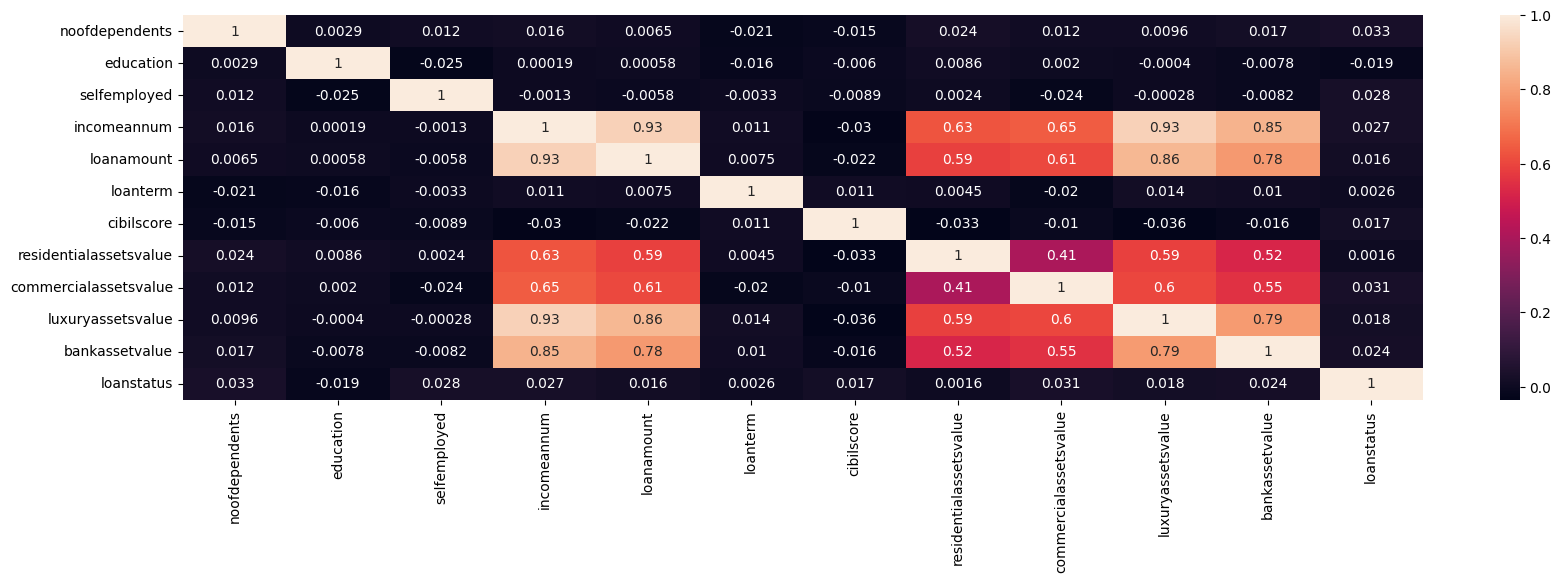

In [106]:
# Corr with heat Map
plt.figure(figsize=(20,5))
sns.heatmap(trainingFrame.corr(),annot=True)

In [108]:
# Realationship is non linear, xgboost is a go to Model
model=XGBClassifier(learning_rate=0.1, reg_alpha=0.1,reg_lambda=0.1)
model.fit(xTrain,yTrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [66]:
# Prediction
prediction=model.predict(xTest)

In [74]:
# Compute classification report
modelReport=classification_report(yTest,prediction,target_names=labelEncoder.classes_,output_dict=True)

In [75]:
modelReport

{'Approved': {'precision': 0.9848024316109423,
  'recall': 0.9863013698630136,
  'f1-score': 0.9855513307984791,
  'support': 657.0},
 'Rejected': {'precision': 0.9780487804878049,
  'recall': 0.975669099756691,
  'f1-score': 0.976857490864799,
  'support': 411.0},
 'accuracy': 0.9822097378277154,
 'macro avg': {'precision': 0.9814256060493736,
  'recall': 0.9809852348098523,
  'f1-score': 0.9812044108316391,
  'support': 1068.0},
 'weighted avg': {'precision': 0.9822034141843416,
  'recall': 0.9822097378277154,
  'f1-score': 0.9822056676779337,
  'support': 1068.0}}

In [76]:
reportFrame=pd.DataFrame(modelReport).transpose()

In [77]:
reportFrame

,precision,recall,f1-score,support
Approved,0.984802,0.986301,0.985551,657.00000
Rejected,0.978049,0.975669,0.976857,411.00000
accuracy,0.982210,0.982210,0.982210,0.98221
macro avg,0.981426,0.980985,0.981204,1068.00000
weighted avg,0.982203,0.982210,0.982206,1068.00000


In [83]:
# computer probability
probability=model.predict_proba(xTest)

In [84]:
model.classes_

array([0, 1])

In [86]:
probability

array([[9.3802035e-01, 6.1979655e-02],
       [9.9935287e-01, 6.4711424e-04],
       [9.9977708e-01, 2.2292610e-04],
       ...,
       [9.9973762e-01, 2.6238640e-04],
       [1.0090470e-03, 9.9899095e-01],
       [5.0413609e-04, 9.9949586e-01]], shape=(1068, 2), dtype=float32)

In [95]:
probaFrame=pd.DataFrame(probability,columns=labelEncoder.classes_)

In [96]:
probaFrame

,Approved,Rejected
0,0.938020,0.061980
1,0.999353,0.000647
2,0.999777,0.000223
3,0.999122,0.000878
4,0.999664,0.000336
...,...,...
1063,0.990698,0.009302
1064,0.000575,0.999425
1065,0.999738,0.000262
1066,0.001009,0.998991
